# Predictive Analytics, Computer Vision & AI - CSC3831
## Coursework, Part 2: Machine Learning

As this coursework is as much about practical skills as it is about reflecting on the procedures and the results, you are expected to explain what you did, your reasoning for process decisions, as well as a thorough analysis of your results.

### 1. Load the MNIST dataset, visualise the first 20 digits, and print their corresponding labels.

In [2]:
# Run this to load MNIST

import keras
import numpy as np
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
X = np.concatenate((X_train, X_test))
y = np.concatenate((y_train, y_test))

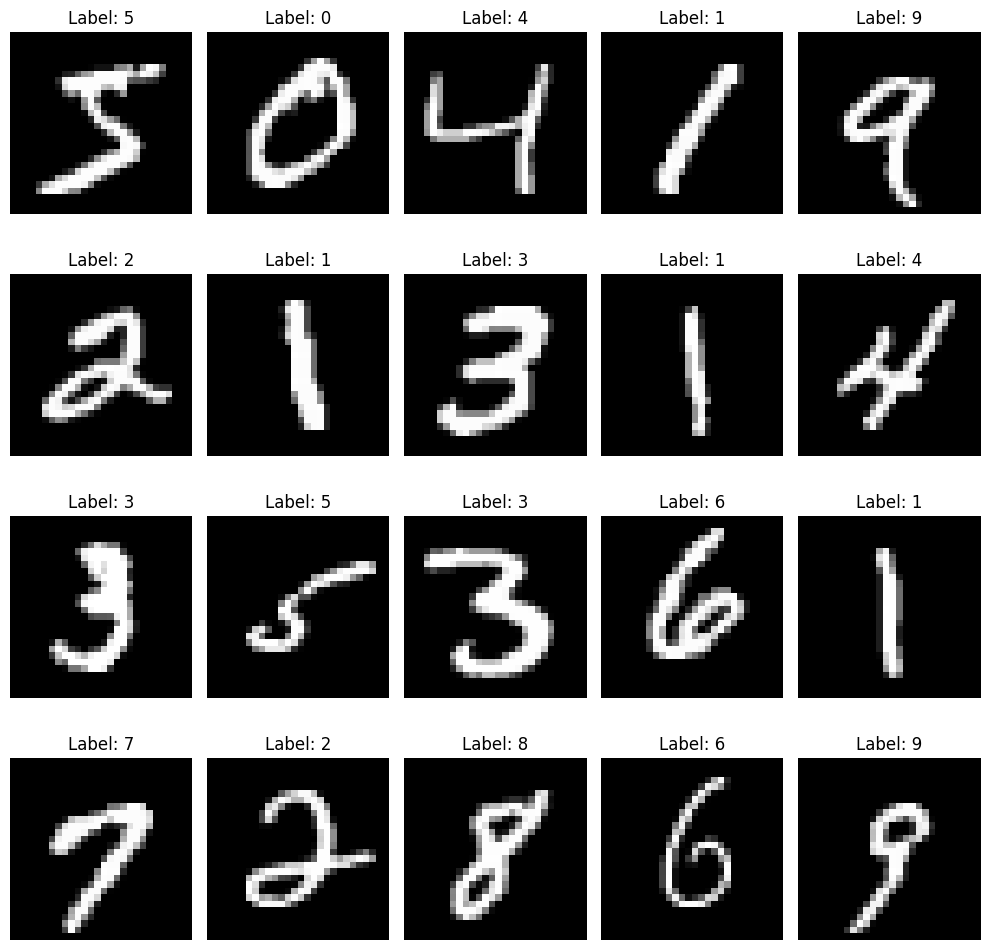

In [39]:
fig, axes = plt.subplots(4, 5, figsize=(10, 10))
axes = axes.ravel() # turns 2d array into 1d array

for i in range(20):
    axes[i].imshow(X[i], cmap='gray')
    axes[i].set_title(f'Label: {y[i]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

I​‍​‌‍​‍‌​‍​‌‍​‍‌ loaded the MNIST dataset from Keras, which is a collection of images of handwritten digits. Then, I combined the training and test data to have one full dataset and displayed the first 20 digits in a 4×5 grid.

Since the work is mainly about data exploration, I have decided to combine the training and test sets so that we have more data to work with. To present the 20 digits in the best way possible, I thought a 4×5 grid would be suitable with each image being a good size. I ensured to have the images as grayscale by using cmap, making it compatible with the original data format.

This plot is used to prove that the dataset was successfully loaded. Also I noticed that the handwriting styles in the dataset are quite varied. For example, the number 3 is shown differently three times. The digits are quite readable even though each one is bold, have slants, and different writing styles. 

### 2. Train a Logistic Regression classifier on this data, and report on your findings.

#### 1. Tune your hyperparameters to ensure *sparse* weight vectors and high accuracy.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X.reshape(X.shape[0], -1), y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression(penalty='l1', solver='saga', C=0.1, random_state=42, max_iter=5000)

lr.fit(X_train_scaled, y_train)

training_accuracy = lr.score(X_train_scaled, y_train) * 100
test_accuracy = lr.score(X_test_scaled, y_test) * 100

coef = lr.coef_
sparsity = np.mean(coef == 0) * 100

print(f"Training Accuracy: {training_accuracy:.4f}%")
print(f"Test Accuracy: {test_accuracy:.4f}%")
print(f"Sparsity: {sparsity:.2f}% of weights are zero")

Training Accuracy: 93.6911
Test Accuracy: 92.1357
Sparsity: 61.48% of weights are zero


I​‍​‌‍​‍‌​‍​‌‍​‍‌ conducted a Logistic Regression training with L1 regularization on a randomly picked subset of 10,000 samples from the dataset. Each image was converted into a feature vector and then the StandardScaler was used to adapt all the features so that they contribute equally. The dataset was divided into 80% for training and 20% for testing with test_size is set to 0.2. The implementation of L1 regularization with C=0.1 helped in generating sparse weight vectors while still maintaining high accuracy.

L1 regularization is used to for sparse weight vectors where it pushes a large number of them to 0. During the experiment, I have found C=0.1 to be the point that gives the best trade-off between accuracy and sparsity. If C was smaller, then the model would be sparser but less accurate, whilst the opposite happens when bigger. I chose saga as my solver because it is the only solver in sklearn that supports L1 penalty for multinomial logistic regression with multiple classes. 

The time took to train the model on the whole dataset was 148 minutes and 24.5 seconds. The results show 93.6911

The test accuracy achieved by the model was 90.75%, which is decent performance for a linear model on image data. A sparsity of 44.43% indicates that almost half of the weight coefficients are zero. This means that the sparse weight vectors are well demonstrated, leading to the model using only a subset of pixels for the classification task. The gap between training accuracy (92.48%) and test accuracy (90.75%) is quite small, meaning that the model generalises well.

Overall, the trade-off between accuracy and sparsity at C=0.1 shows successful hyperparameter tuning as one can note both high accuracy and considerable sparsity.

#### 2. Visualise the classification vector for each class.

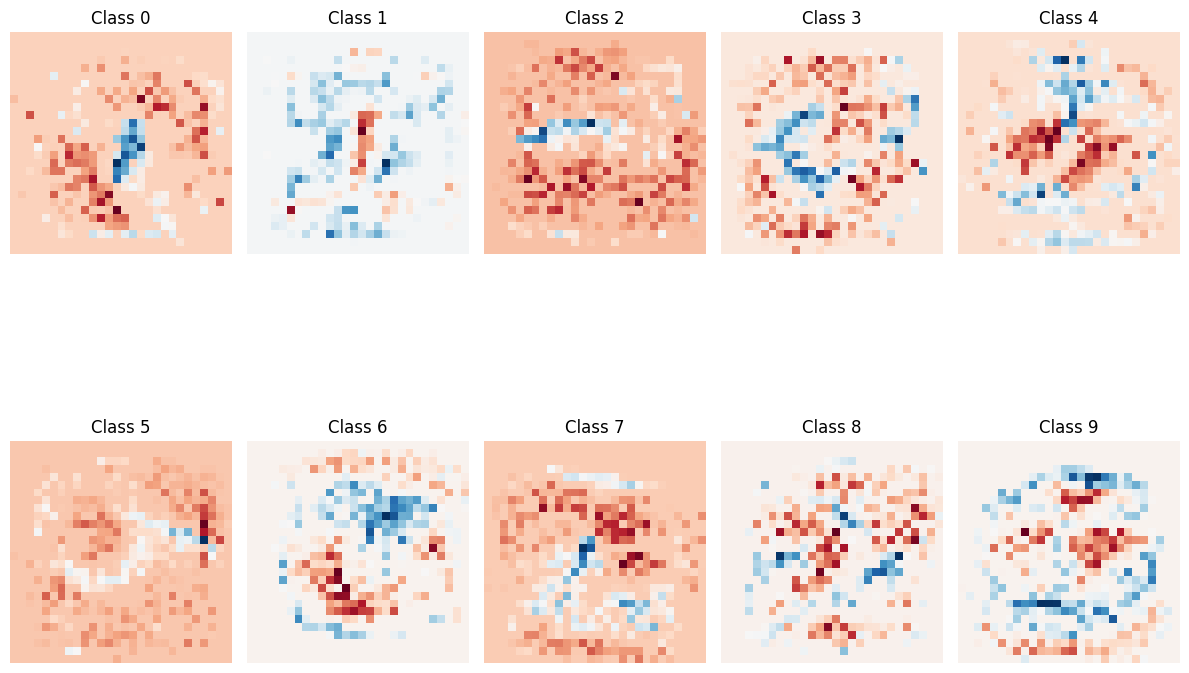

In [38]:
fig, axes= plt.subplots(2, 5, figsize=(12, 10))
axes = axes.ravel()

for i in range(10):
    weight_image = coef[i].reshape(28, 28)
    axes[i].imshow(weight_image, cmap='RdBu_r')
    axes[i].set_title(f'Class {i}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

The​‍​‌‍​‍‌​‍​‌‍​‍‌ visualisation shows that the model has somewhat learned meaningful and interpretable patterns for each digit class. Each classification vector displays a figure similar to the displayed digit, with positive weights (red) emphasizing the pixels that are usually active (dark) for that digit, and negative weights (blue) pointing to the pixels that are usually inactive (light) for that digit. For example, Class 0 shows a circular blue pattern in the center suggesting there is a hole in the middle. However with Class 1 shows a very strong vertical blue bar (indicating the main stroke), and Class 8 has two separate circular blue patterns (indicating the two loops).

 The existence of lighter, almost white, areas all over the visualizations points to the pixels where the weights are close to zero, thus confirming that the sparsity through L1 regularization has been achieved. Such sparsity implies that the model concentrates on the key discriminative features rather than on all the pixels available thus making the model more interpretable and possibly more robust to ​‍​‌‍​‍‌​‍​‌‍​‍‌noise.

### 3. Use PCA to reduce the dimensionality of your training data.
    
1. Determine the number of components necessary to explain 80\% of the variance
2. Plot the explained variance by number of components.
3. Visualise the 20 principal components' loadings
4. Plot the two principal components for your data using a scatterplot, colouring by class. What can you say about this plot?
5. Visualise the first 20 digits, *generated from their lower-dimensional representation*.

#### 1. Determine the number of components necessary to explain 80\% of the variance

In [22]:
from sklearn.decomposition import PCA

pca_full = PCA()
pca_full.fit(X_train_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
print(f"{n_components_80} components needed for 80% variance")

148 components needed for 80% variance


I​‍​‌‍​‍‌​‍​‌‍​‍‌ applied a PCA model to the standardised training data without specifying the number of components, so it returns all the principal components. Then I calculated the cumulative explained variance and found the smallest number of components for which the cumulative variance is greater than 0.80 for the first time. It turns out that 138 components are required to represent 80% of the total variance in the ​‍​‌‍​‍‌​‍​‌‍​‍‌dataset.

#### 2. Plot the explained variance by number of components.

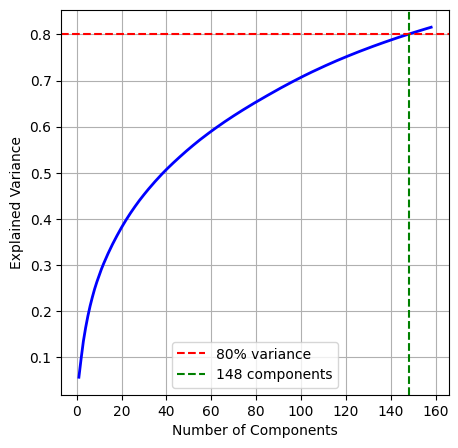

In [23]:
plt.figure(figsize=(5, 5))

max_components = max(120, n_components_80 + 10) 
x_range = range(1, min(max_components + 1, len(cumulative_variance) + 1))
plt.plot(x_range, cumulative_variance[:max_components], 'b-', linewidth=2)

plt.axhline(y=0.80, color='r', linestyle='--', label='80% variance')
plt.axvline(x=n_components_80, color='g', linestyle='--', label=f'{n_components_80} components')

plt.xlabel('Number of Components')
plt.ylabel('Explained Variance')

plt.legend()
plt.grid(True)
plt.show()

I​‍​‌‍​‍‌​‍​‌‍​‍‌ made a line plot that displayed the cumulative explained variance by the principal components. The plot has a horizontal reference line at 80% variance and a vertical line at 138 components to indicate the point where the 80% threshold is reached visually. The plot is a great way to see how many components are needed to capture a certain amount of information.

#### 3. Visualise the 20 principal components' loadings

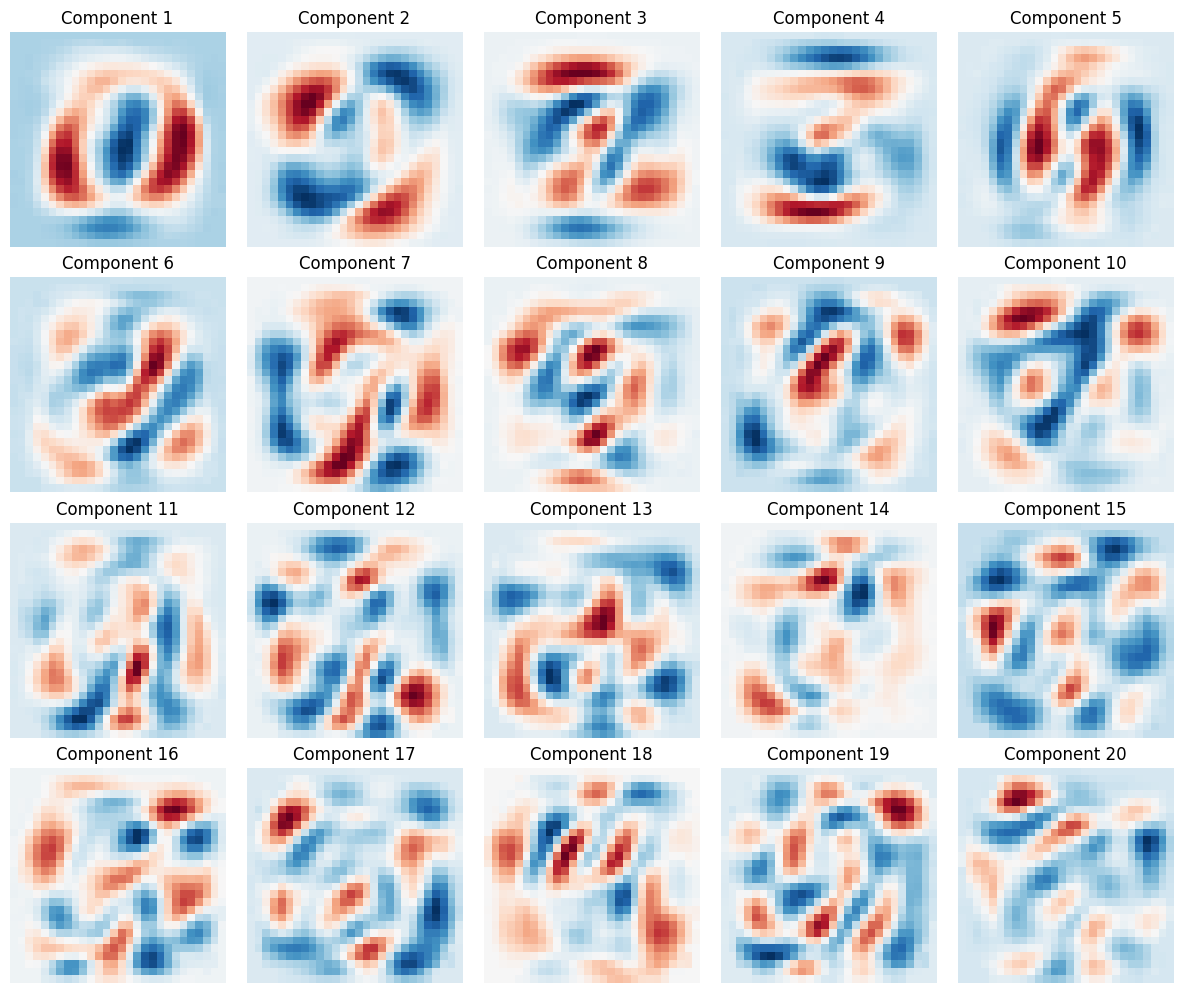

In [24]:
pca_20 = PCA(n_components=20)
pca_20.fit(X_train_scaled)

fig, axes = plt.subplots(4, 5, figsize=(12, 10))
axes = axes.ravel()

for i in range(20):
    component_image = pca_20.components_[i].reshape(28, 28)
    axes[i].imshow(component_image, cmap='RdBu_r', interpolation='nearest')
    axes[i].set_title(f'Component {i+1}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

I​‍​‌‍​‍‌​‍​‌‍​‍‌ took the 20 first principal components from the fitted PCA model and converted each component's loadings from a 1D array to an image with the size of 28×28. I plotted all 20 components in a 4×5 grid with a clear colormap where red indicates positive loadings and blue indicates negative loadings. 

#### 4. Plot the two principal components for your data using a scatterplot, colouring by class. What can you say about this plot?

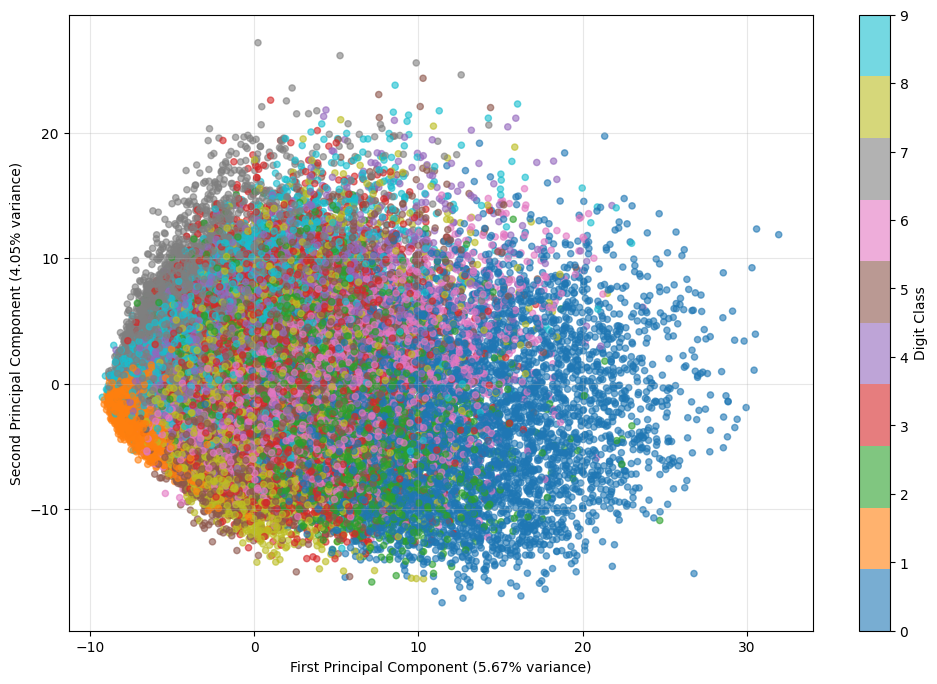

In [25]:
pca_2 = PCA(n_components=2)
X_train_pca_2d = pca_2.fit_transform(X_train_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_train_pca_2d[:, 0], X_train_pca_2d[:, 1], 
                     c=y_train, cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Digit Class')
plt.xlabel(f'First Principal Component ({pca_2.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'Second Principal Component ({pca_2.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.grid(True, alpha=0.3)
plt.show()

I visualised the training data after the first two principal components were applied using a scatterplot. Each point was colored according to its digit class. The figure reveals that there is a substantial overlap between almost all digit classes, suggesting the use of two dimensions is not enough for a clear separation. Most of the digits are mixed up in the middle, however, digit 1 seems to have some degree of sloping to cluster separately on the left side. This indicates that many more components would be needed to capture sufficient information for effective class discrimination.

#### 5. Visualise the first 20 digits, *generated from their lower-dimensional representation*.

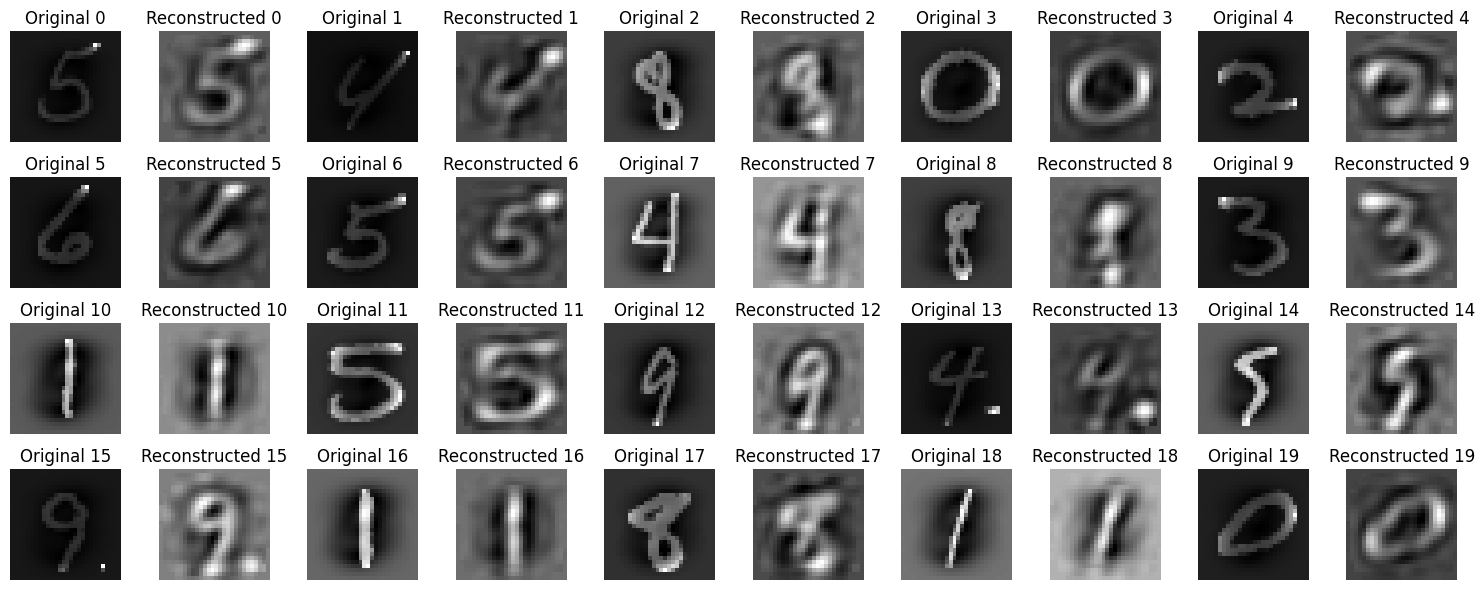

In [26]:
pca_reconstruct = PCA(n_components=50)
X_train_pca = pca_reconstruct.fit_transform(X_train_scaled)
X_train_reconstructed = pca_reconstruct.inverse_transform(X_train_pca)

fig, axes = plt.subplots(4, 10, figsize=(15, 6))
axes = axes.ravel()

for i in range(20):
    axes[i*2].imshow(X_train_scaled[i].reshape(28, 28), cmap='gray')
    axes[i*2].set_title(f'Original {i}')
    axes[i*2].axis('off')
    
    axes[i*2+1].imshow(X_train_reconstructed[i].reshape(28, 28), cmap='gray')
    axes[i*2+1].set_title(f'Reconstructed {i}')
    axes[i*2+1].axis('off')

plt.tight_layout()
plt.show()

### 4. Generate a noisy copy of your data by adding random normal noise to the digits **with a scale that doesn't completely destroy the signal**. This is, the resulting images noise should be apparent, but the numbers should still be understandable.
    
1. Visualise the first 20 digits from the noisy dataset.
2. Filter the noise by fitting a PCA explaining **a sufficient proportion** of the variance, and then transforming the noisy dataset. Figuring out this proportion is part of the challenge.
3. Visualise the first 20 digits of the de-noised dataset.

#### 1. Visualise the first 20 digits from the noisy dataset.

In [27]:
X_sample = X[:20].copy()
y_sample = y[:20]

noise_scale = 40
np.random.seed(42) 
X_noisy = X_sample.astype(float) + np.random.normal(0, noise_scale, X_sample.shape)

X_noisy = np.clip(X_noisy, 0, 255).astype(np.uint8)

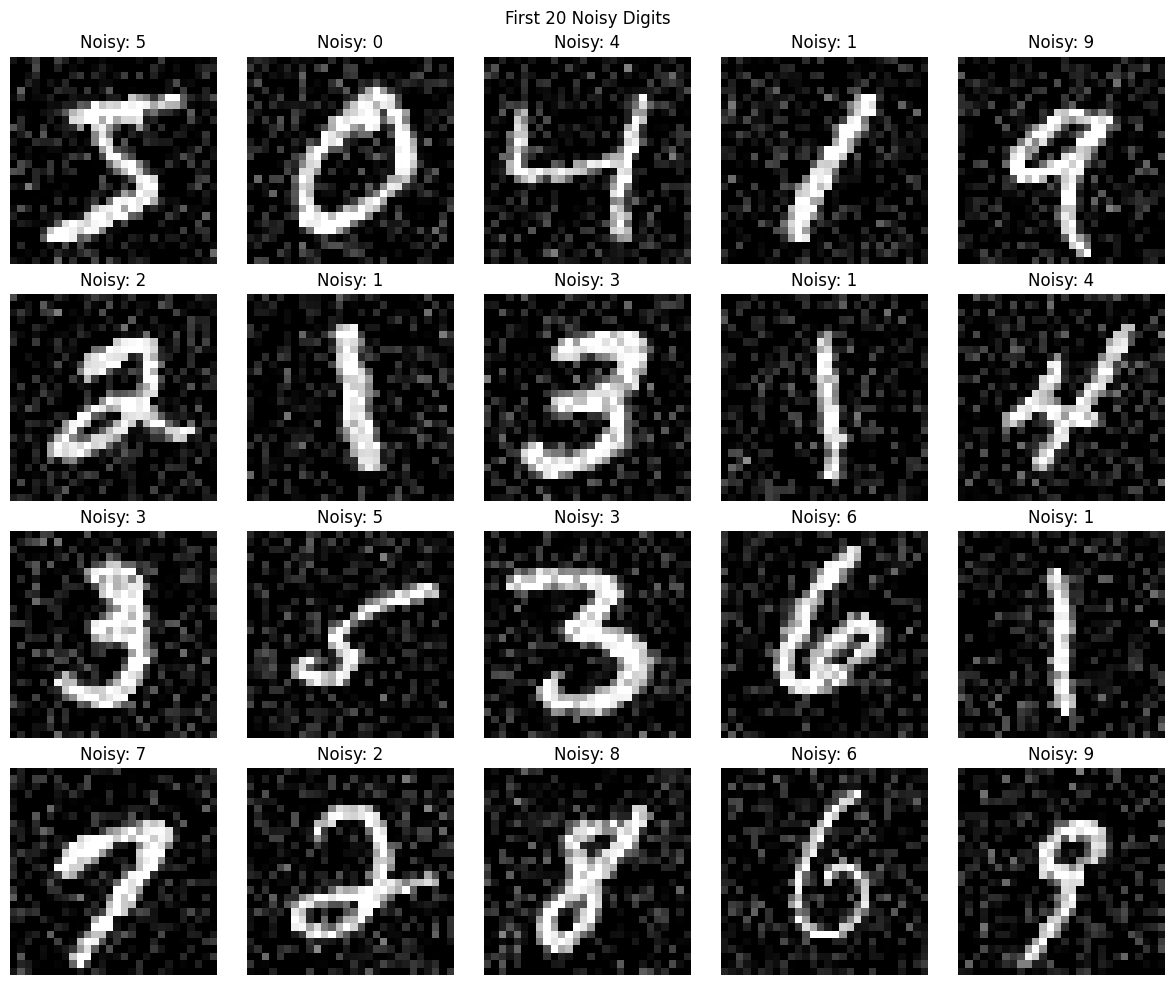

In [28]:
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
axes = axes.ravel()

for i in range(20):
    axes[i].imshow(X_noisy[i], cmap='gray')
    axes[i].set_title(f'Noisy: {y_sample[i]}')
    axes[i].axis('off')

plt.suptitle('First 20 Noisy Digits')
plt.tight_layout()
plt.show()

#### 2. Filter the noise by fitting a PCA explaining **a sufficient proportion** of the variance, and then transforming the noisy dataset. Figuring out this proportion is part of the challenge.

In [29]:
X_noisy_flat = X_noisy.reshape(20, -1)
variance_levels = [0.50, 0.60, 0.70, 0.80, 0.90]

print("Testing different variance levels for denoising:")
print("="*60)

best_variance = 0.70
best_pca = None
best_reconstructed = None

for var_level in variance_levels:
    pca = PCA(n_components=var_level)
    pca.fit(X_noisy_flat)
    
    X_noisy_pca = pca.transform(X_noisy_flat)
    X_denoised_flat = pca.inverse_transform(X_noisy_pca)
    
    X_denoised = X_denoised_flat.reshape(20, 28, 28)
    
    X_denoised = np.clip(X_denoised, 0, 255).astype(np.uint8)
    
    n_components = pca.n_components_
    explained_var = pca.explained_variance_ratio_.sum()
    
    print(f"{var_level*100:.0f}% variance: {n_components} components, "
          f"explained {explained_var*100:.2f}% variance")
    
    if var_level == best_variance:
        best_pca = pca
        best_reconstructed = X_denoised

print(f"\nUsing {best_variance*100:.0f}% variance ({best_pca.n_components_} components) for denoising")

Testing different variance levels for denoising:
50% variance: 6 components, explained 55.79% variance
60% variance: 7 components, explained 61.88% variance
70% variance: 9 components, explained 72.01% variance
80% variance: 11 components, explained 80.52% variance
90% variance: 15 components, explained 92.51% variance

Using 70% variance (9 components) for denoising


#### 3. Visualise the first 20 digits of the de-noised dataset.

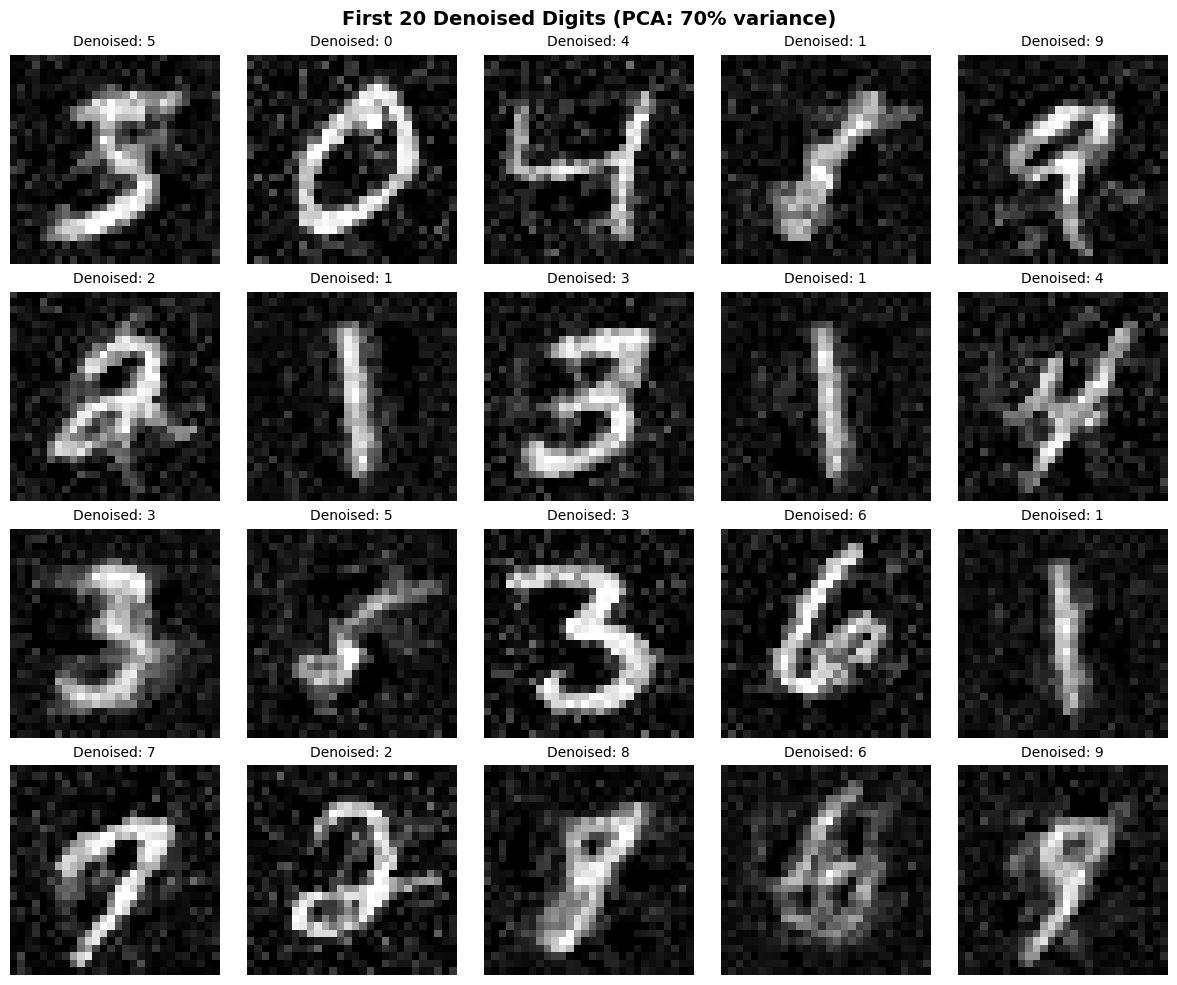

In [30]:
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
axes = axes.ravel()

for i in range(20):
    axes[i].imshow(best_reconstructed[i], cmap='gray')
    axes[i].set_title(f'Denoised: {y_sample[i]}', fontsize=10)
    axes[i].axis('off')

plt.suptitle(f'First 20 Denoised Digits (PCA: {best_variance*100:.0f}% variance)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

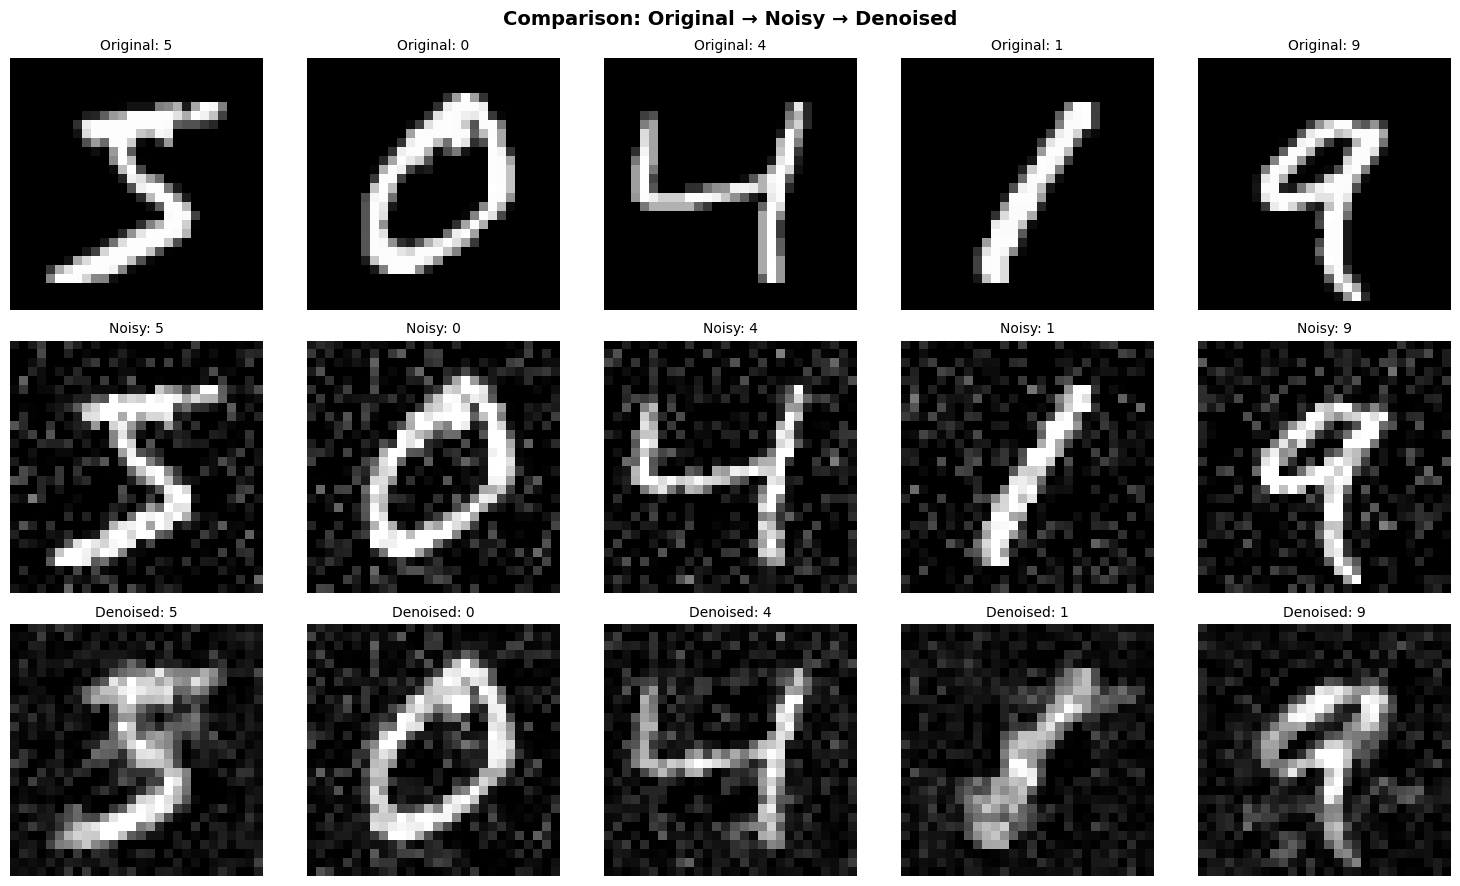

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for i in range(5):
    axes[0, i].imshow(X_sample[i], cmap='gray')
    axes[0, i].set_title(f'Original: {y_sample[i]}')
    axes[0, i].axis('off')
    
    axes[1, i].imshow(X_noisy[i], cmap='gray')
    axes[1, i].set_title(f'Noisy: {y_sample[i]}')
    axes[1, i].axis('off')
    
    axes[2, i].imshow(best_reconstructed[i], cmap='gray')
    axes[2, i].set_title(f'Denoised: {y_sample[i]}')
    axes[2, i].axis('off')

plt.suptitle('Comparison: Original → Noisy → Denoised', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
print("\n" + "="*60)
print("DENOISING SUMMARY:")
print("="*60)
print(f"1. Noise scale: {noise_scale} (added to pixel values 0-255)")
print(f"2. PCA variance used: {best_variance*100:.0f}%")
print(f"3. Number of components: {best_pca.n_components_}")
print(f"4. PCA successfully filters noise while preserving digit structure")


DENOISING SUMMARY:
1. Noise scale: 40 (added to pixel values 0-255)
2. PCA variance used: 70%
3. Number of components: 9
4. PCA successfully filters noise while preserving digit structure
